In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score
import sys
sys.path.append('..')

print("Libraries imported successfully")

Libraries imported successfully


In [12]:
clean_df = pd.read_csv('../data/featured_transactions_v2.csv')
clean_df['Timestamp'] = pd.to_datetime(clean_df['Timestamp'])
cutoff = clean_df['Timestamp'].quantile(0.8)
test = clean_df[clean_df['Timestamp'] > cutoff]


attacked_datasets = {
    'amount_scaling': pd.read_csv('../data/attacked_transactions_amount_scaling.csv'),
    'category_mimicry': pd.read_csv('../data/attacked_transactions_category_mimicry.csv'),
    'time_shift': pd.read_csv('../data/attacked_transactions_time_shift.csv'),
    'velocity_spacing': pd.read_csv('../data/attacked_transactions_velocity_spacing.csv'),
    'combined': pd.read_csv('../data/attacked_transactions_combined.csv')
}

model_names = ['lr_balanced', 'rf_balanced', 'xgb_balanced', 'lr_naive', 'rf_naive', 'xgb_naive']
models = {name: joblib.load(f'../results/models/{name}.pkl') for name in model_names}

print(f"Clean test data shape: {test.shape}")
print(f"Models loaded: {list(models.keys())}")

Clean test data shape: (56895, 13)
Models loaded: ['lr_balanced', 'rf_balanced', 'xgb_balanced', 'lr_naive', 'rf_naive', 'xgb_naive']


In [18]:
feature_cols = ['amount_zscore', 'transactions_last_1h', 'amount_sum_last_24h', 'log_time_since_last_txn',  'is_new_category', 'is_foreign', 
               'hour_of_day', 'is_night']

scaler = joblib.load('../results/models/scaler.pkl')
X_clean = pd.DataFrame(scaler.transform(test[feature_cols]),columns=feature_cols)
y_clean = test['is_fraud']

attack_names = [
    'amount_scaling',
    'time_shift',
    'category_mimicry',
    'velocity_spacing',
    'combined'
]

def get_clean_threshold(model, X_clean, y_clean):
    """Get optimal threshold from clean data once per model."""
    y_proba = model.predict_proba(X_clean)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_clean, y_proba)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = f1s[:-1].argmax()
    return thresholds[best_idx]

def evaluate_robustness(model, X_attacked, y_attacked, fixed_threshold):
    """Evaluate on attacked data using the clean-optimal threshold."""
    y_proba = model.predict_proba(X_attacked)[:, 1]
    y_pred = (y_proba >= fixed_threshold).astype(int)
    return {
        'recall': recall_score(y_attacked, y_pred, zero_division=0),
        'precision': precision_score(y_attacked, y_pred, zero_division=0),
        'f1': f1_score(y_attacked, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_attacked, y_proba)
    }

results = []

for model_name, model in models.items():
    # Step 1: get fixed threshold from clean data once per model
    fixed_threshold = get_clean_threshold(model, X_clean, y_clean)
    clean_metrics = evaluate_robustness(model, X_clean, y_clean, fixed_threshold)
    print(f"{model_name} | clean threshold: {fixed_threshold:.3f} | clean recall: {clean_metrics['recall']:.3f}")

    for attack_name in attack_names:
        # Step 2: load attacked data
        attacked_df = pd.read_csv(f'../data/attacked_transactions_{attack_name}.csv')
        X_attacked = pd.DataFrame(
            scaler.transform(attacked_df[feature_cols]),
            columns=feature_cols
        )
        y_attacked = attacked_df['is_fraud']

        # Step 3: evaluate using fixed threshold
        attacked_metrics = evaluate_robustness(model, X_attacked, y_attacked, fixed_threshold)

        results.append({
            'model': model_name,
            'attacker': attack_name,
            'clean_recall': clean_metrics['recall'],
            'attacked_recall': attacked_metrics['recall'],
            'recall_drop': clean_metrics['recall'] - attacked_metrics['recall'],
            'clean_f1': clean_metrics['f1'],
            'attacked_f1': attacked_metrics['f1'],
            'roc_auc': attacked_metrics['roc_auc']
        })

results_df = pd.DataFrame(results)
results_df.to_csv('../results/robustness_results.csv', index=False)

print("\nRobustness results saved!")
print(results_df)

lr_balanced | clean threshold: 0.785 | clean recall: 0.631
rf_balanced | clean threshold: 0.702 | clean recall: 0.826
xgb_balanced | clean threshold: 0.491 | clean recall: 0.826
lr_naive | clean threshold: 0.186 | clean recall: 0.455
rf_naive | clean threshold: 0.186 | clean recall: 0.814
xgb_naive | clean threshold: 0.129 | clean recall: 0.827

Robustness results saved!
           model          attacker  clean_recall  attacked_recall  \
0    lr_balanced    amount_scaling      0.630962         0.753975   
1    lr_balanced        time_shift      0.630962         0.630962   
2    lr_balanced  category_mimicry      0.630962         0.563180   
3    lr_balanced  velocity_spacing      0.630962         0.766527   
4    lr_balanced          combined      0.630962         0.400000   
5    rf_balanced    amount_scaling      0.825941         0.769874   
6    rf_balanced        time_shift      0.825941         0.493724   
7    rf_balanced  category_mimicry      0.825941         0.727197   
8    

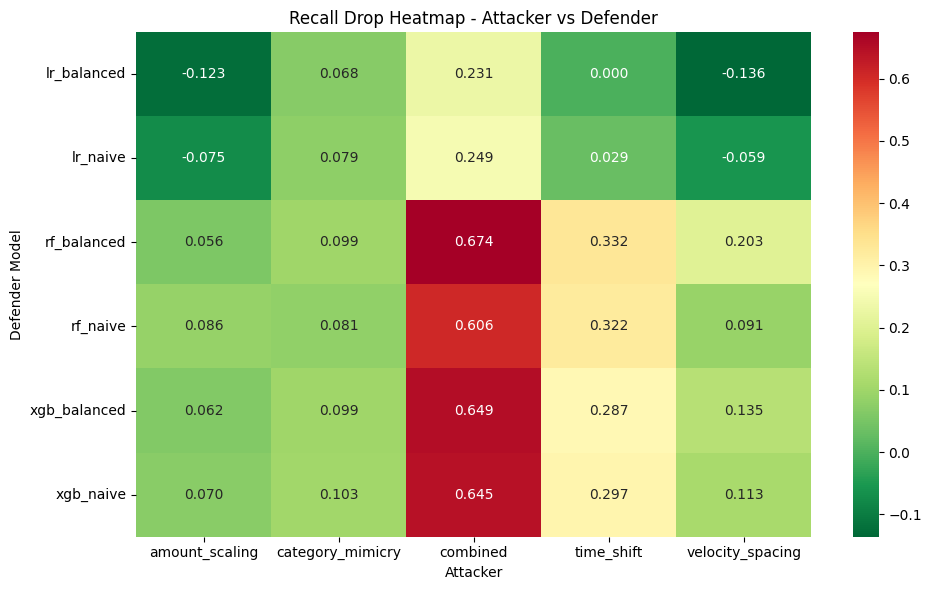

In [19]:
heatmap_data = results_df.pivot(index='model', columns='attacker', values='recall_drop')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn_r')
plt.title('Recall Drop Heatmap - Attacker vs Defender')
plt.ylabel('Defender Model')
plt.xlabel('Attacker')
plt.tight_layout()
plt.show()

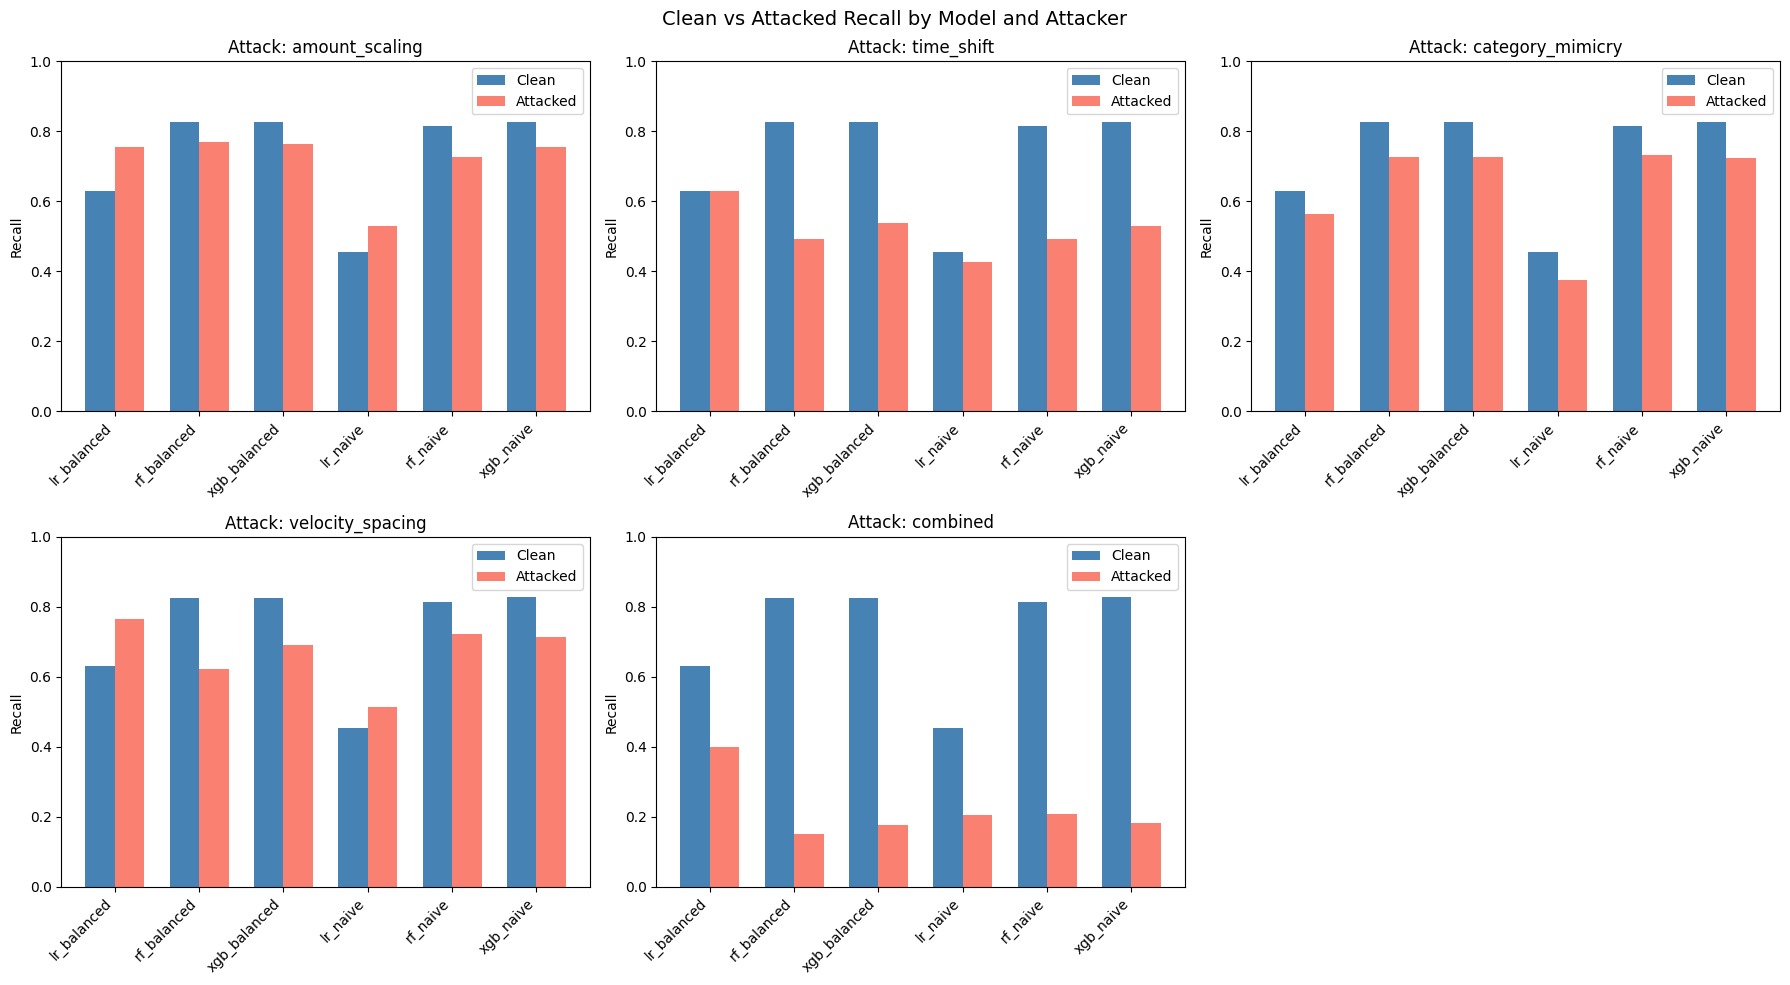

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

attackers = results_df['attacker'].unique()

for i, attacker in enumerate(attackers):
    ax = axes[i]
    attacker_data = results_df[results_df['attacker'] == attacker]
    
    x = np.arange(len(attacker_data))
    width = 0.35
    
    # plot clean recall bars
    ax.bar(x - width/2, attacker_data['clean_recall'], width, label='Clean', color='steelblue')
    
    # plot attacked recall bars — have a go at this line
    ax.bar(x + width/2, attacker_data['attacked_recall'], width, label='Attacked', color='salmon')
    
    ax.set_title(f'Attack: {attacker}')
    ax.set_xticks(x)
    ax.set_xticklabels(attacker_data['model'], rotation=45, ha='right')
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1)
    ax.legend()

axes[5].set_visible(False)

plt.suptitle('Clean vs Attacked Recall by Model and Attacker', fontsize=14)
plt.tight_layout()
plt.show()

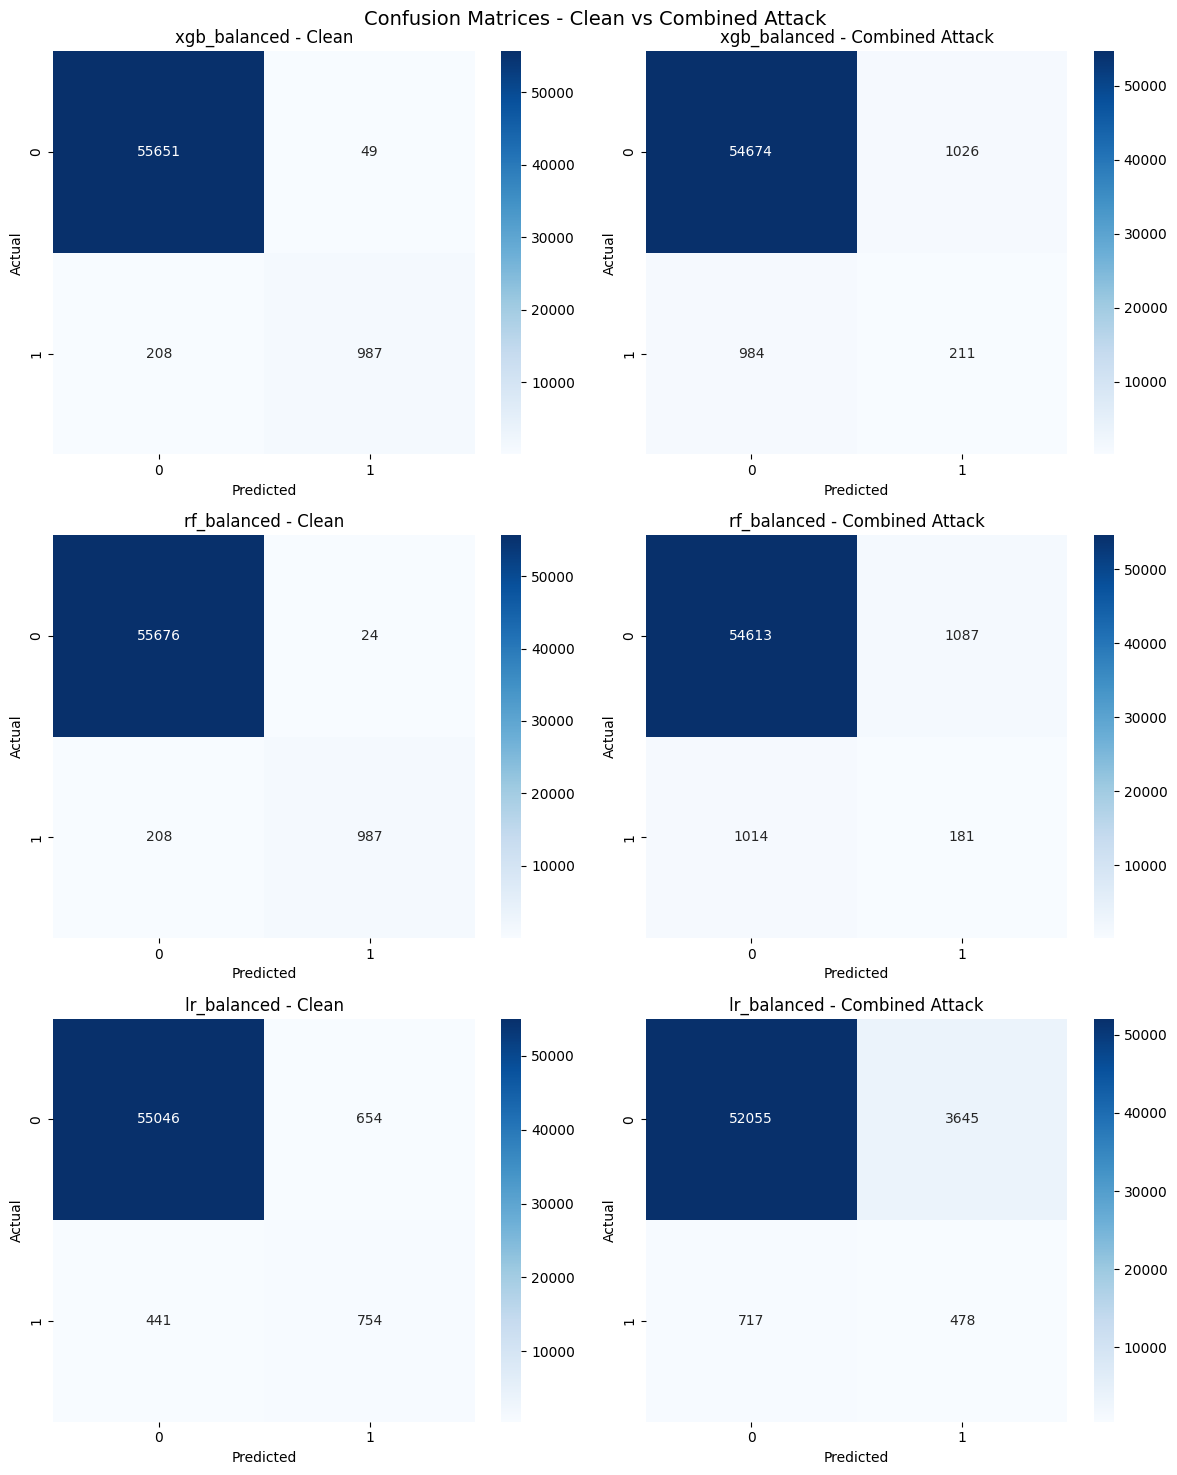

In [23]:
combined_df = attacked_datasets['combined']
X_attacked_combined = pd.DataFrame(scaler.transform(combined_df[feature_cols]), columns=feature_cols)
y_attacked_combined = combined_df['is_fraud']

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

models_to_plot = ['xgb_balanced', 'rf_balanced', 'lr_balanced']

for i, model_name in enumerate(models_to_plot):
    model = models[model_name]

    # get fixed threshold for this model
    fixed_threshold = get_clean_threshold(model, X_clean, y_clean)
    
    # clean predictions
    y_pred_clean = (model.predict_proba(X_clean)[:, 1] >= fixed_threshold).astype(int)
    
    # attacked predictions
    y_pred_attacked = (model.predict_proba(X_attacked_combined)[:, 1] >= fixed_threshold).astype(int)
    
    # plot clean
    cm_clean = confusion_matrix(y_clean, y_pred_clean)
    sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues', ax=axes[i][0])
    axes[i][0].set_title(f'{model_name} - Clean')
    axes[i][0].set_ylabel('Actual')
    axes[i][0].set_xlabel('Predicted')
    
    # plot attacked
    cm_attacked = confusion_matrix(y_attacked_combined, y_pred_attacked)
    sns.heatmap(cm_attacked, annot=True, fmt='d', cmap='Blues', ax=axes[i][1])
    axes[i][1].set_title(f'{model_name} - Combined Attack')
    axes[i][1].set_ylabel('Actual')
    axes[i][1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - Clean vs Combined Attack', fontsize=14)
plt.tight_layout()
plt.show()